# Pyro SAI — Task 1: Fire Weather Index and P95 extreme fire-weather days

**Question:** does G6-1.5K SAI (tropical injection, *G6-1.5K-SAI*) or high-latitude injection (*G6-1.5K-HiLLA*) change the frequency, duration and timing of extreme fire weather relative to the SSP2-4.5 background, and relative to the 1.5 K target climate?

**Method (per model):**
1. Daily FWI (Canadian FWI system, `xclim`) from daily **tasmax** (daily-mean `tas` for models lacking tasmax in any scenario, such as UKESM1-1), **min RH** (daily-mean RH if min RH is unavailable), **mean 10 m wind** and **total precipitation**. One spin-up year is computed and discarded.
2. Local **P95 threshold**: 95th percentile of daily FWI, pooled over all days and all SSP2-4.5 members in the **target period 2020–2039**, which is the climate G6-1.5K is designed to hold.
3. For SSP2-4.5, G6-1.5K-SAI and G6-1.5K-HiLLA in **2064–2083**: days per year above P95, days above an absolute threshold (FWI > 30), longest spell above P95, monthly exceedance frequency (seasonality), and fire-season mean FWI. The fire season is the three consecutive months with the highest target-period FWI at each grid cell.
4. Significance: Welch t-test on annual values (members × years) with Benjamini–Hochberg FDR control (α_FDR = 0.10). Multi-model robustness requires at least ⅔ of models to agree on the sign and at least half to be individually significant.
5. AR6 land-region statistics (area-weighted, land only) for the focus regions.
6. *(Optional)* **Driver attribution** (delta method): perturb SSP2-4.5 daily inputs with the G6-minus-SSP2-4.5 monthly climatological change of one driver at a time (T, RH, wind, precipitation). This separates cooling from drying.

**Inputs:** `pyrosai_catalog.json` (built by `00_Data_Discovery.ipynb`) and `pyrosai.py` (same folder).
**Outputs:** daily FWI Zarr stores (for Task 4 / the Living Data Product), `task1_<model>_summary.nc`, `task1_multimodel_1deg.nc`, the regional CSV, and figures in `pyrosai_output/figures/`.

**Resources:** designed for the default 30 GB / 4 CPU Hub profile. Work is chunked in space, with each grid block's full time series kept in one chunk. Every expensive step is cached, so an interrupted run resumes where it stopped.

In [1]:
import os, sys, json, warnings, subprocess, time
for pkg in ("xclim", "regionmask"):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

import numpy as np
import pandas as pd
import xarray as xr
import dask
import matplotlib.pyplot as plt
import xclim, regionmask

sys.path.insert(0, os.getcwd())
import pyrosai as P

warnings.filterwarnings("ignore", category=RuntimeWarning)   # all-NaN slices over ocean etc.
xr.set_options(keep_attrs=True)
print({m.__name__: m.__version__ for m in (np, pd, xr, dask, xclim, regionmask)})

{'numpy': '2.0.2', 'pandas': '2.2.3', 'xarray': '2025.1.1', 'dask': '2025.1.0', 'xclim': '0.54.0', 'regionmask': '0.13.0'}


## Configuration
Edit this cell. Everything below it runs top to bottom without edits.

In [2]:
CATALOG_PATH    = "pyrosai_catalog.json"   # from 00_Data_Discovery.ipynb (review it first!)
# Big intermediate products (staged inputs, daily FWI). Local disk is small on the Hub,
# so use your persistent-prod prefix, e.g. "s3://reflective-persistent-prod/<username>/pyrosai"
WORK_ROOT       = "s3://reflective-persistent-prod/<username>/pyrosai"
STORAGE_OPTIONS = None                     # fsspec options for WORK_ROOT (None = Hub default creds)
OUT_DIR         = "./pyrosai_output"       # small outputs: NetCDF summaries, CSV, figures

MODELS          = None       # None = every model with all 3 scenarios and FWI variables; or e.g. ["CESM2-WACCM"]
MAX_MEMBERS     = 3
TARGET_PERIOD   = P.TARGET_PERIOD          # (2020, 2039)
ASSESS_PERIOD   = P.ASSESS_PERIOD          # (2064, 2083)
BBOX            = None       # (lon0, lon1, lat0, lat1) for a quick regional dry-run, e.g. (-130, -100, 30, 60)

STAGE_INPUTS    = True       # stage daily inputs to time-contiguous Zarr (read NetCDF once; reused by Task 2)
SPACE_CHUNK     = 48         # grid points per chunk side (48x48 x 7665 days ~ 2 GB per task)

FWI_TEMP        = "auto"     # "auto": tasmax if ALL scenarios have it, else tas (per model, for consistency)
FWI_RH, FWI_RH_FALLBACK = "hursmin", "hurs"
FWI_KEEP        = ("FWI",)   # add "ISI", "BUI", "DC" to archive components (x storage)
P95             = 0.95
ABS_FWI         = 30.0       # absolute "very high" threshold (days above it per year)
ALPHA_FDR       = 0.10
COMMON_RES      = 1.0        # degrees, multi-model / atlas grid
FOCUS_REGIONS   = P.FOCUS_REGIONS

RUN_ATTRIBUTION = True       # delta-method driver attribution (10 extra FWI runs on one member per model)
ATTRIB_MEMBER   = 0          # index of SSP2-4.5 member used as the baseline weather

USE_DASK_CLUSTER = True      # 4 single-threaded workers for the 30 GB / 4 CPU profile
OVERWRITE_METRICS = False

# ---- personal overrides: put your edits in local_config.py (survives notebook updates) ----
if os.path.exists("local_config.py"):
    exec(open("local_config.py").read())
    print("applied local_config.py")

# ---- automated test mode (synthetic data; ignore on the Hub) ----
if os.environ.get("PYROSAI_TEST") == "1":
    CATALOG_PATH, WORK_ROOT, OUT_DIR = os.environ["PYROSAI_CATALOG"], "./test_work", "./test_output"
    SPACE_CHUNK, USE_DASK_CLUSTER = 8, False
assert "<username>" not in WORK_ROOT, "Set WORK_ROOT to your persistent-prod prefix (or a local folder) first"

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
INPUT_VARS = ["tasmax", FWI_RH, FWI_RH_FALLBACK, "sfcWind", "pr", "tas"]   # missing optional ones are skipped
RUNS = {"target": ("ssp245", TARGET_PERIOD), "ssp245": ("ssp245", ASSESS_PERIOD),
        "G6-1.5K-SAI": ("G6-1.5K-SAI", ASSESS_PERIOD), "G6-1.5K-HiLLA": ("G6-1.5K-HiLLA", ASSESS_PERIOD)}
EXPS = ["ssp245", "G6-1.5K-SAI", "G6-1.5K-HiLLA"]

applied local_config.py


In [3]:
if USE_DASK_CLUSTER:
    from dask.distributed import LocalCluster, Client
    cluster = LocalCluster(n_workers=4, threads_per_worker=1, memory_limit="6.5GiB")
    client = Client(cluster)
    print("Dask dashboard:", client.dashboard_link)

Dask dashboard: /user/savvyscientist/proxy/8787/status


## 1. Catalog and data availability
Check this table before running anything expensive: each model needs all three scenarios with `tasmax`, `hurs` (or `hursmin`), `sfcWind` and `pr` at daily frequency.

In [4]:
catalog = P.apply_known_issues(P.load_catalog(CATALOG_PATH))   # drops known-bad variables (see pyrosai.KNOWN_BAD_VARIABLES)
ws = P.Workspace(catalog, WORK_ROOT, STORAGE_OPTIONS, SPACE_CHUNK, STAGE_INPUTS, BBOX)
candidates = MODELS or [m for m in catalog if not m.startswith("_")]
rt = P.readiness_table({m: catalog[m] for m in candidates}, ["tasmax", "hurs", "sfcWind", "pr"], MAX_MEMBERS)
display(rt.pivot_table(index=["model", "member"], columns="scenario", values="missing", aggfunc="first").fillna(""))

# wind derived from uas/vas is bias-corrected towards sfcWind (must run before any staging)
P.prepare_wind_corrections(ws, candidates, f"{OUT_DIR}/metrics{ws.tag}")
P.prepare_wind_climatology(ws, candidates, f"{OUT_DIR}/metrics{ws.tag}")

fwi_temp, models = {}, []
for m in candidates:
    t = P.choose_fwi_temp(ws, m, FWI_RH_FALLBACK, None if FWI_TEMP == "auto" else FWI_TEMP)
    if all(ws.members(m, s, [t, FWI_RH_FALLBACK, "sfcWind", "pr"]) for s in P.SCENARIOS):
        models.append(m); fwi_temp[m] = t
    else:
        print(f"[skip] {m}: not all scenarios have {t}, {FWI_RH_FALLBACK}, sfcWind, pr")
members = {m: {s: ws.members(m, s, [fwi_temp[m], FWI_RH_FALLBACK, "sfcWind", "pr"], MAX_MEMBERS)
               for s in P.SCENARIOS} for m in models}
print("Models ready for Task 1:", models)
for m in models:
    print(f"  {m} (FWI temperature = {fwi_temp[m]}): " + ", ".join(f"{s}={members[m][s]}" for s in P.SCENARIOS))
assert models, "No model has all three scenarios with the FWI variables - check the catalog."

[known issue] MIROC-ES2H: removed 'sfcWind' from 6 member(s) - MIROC-ES2H 'sfcWind' files contain a radiative flux (units W/m**2, mean ~160-200), not wind speed (found 2026-10-01)


[wind] MIROC-ES2H: FWI wind = SSP2-4.5 day-of-year climatology of hypot(uas,vas) in ALL scenarios


scenario           G6-1.5K-HiLLA G6-1.5K-SAI         ssp245
model       member                                         
CESM2-WACCM r1                ok          ok               
            r10                               hurs, sfcWind
MIROC-ES2H  r1                ok          ok             ok

[wind] MIROC-ES2H: wind climatology ready (donor MIROC-ES2H/ssp245/r1; mean 2.86 m/s)


  [time] dropping 23742 duplicated time steps (overlapping files)


...

  [time] dropping 1 duplicated time steps (overlapping files)


  [time] dropping 1 duplicated time steps (overlapping files)


  [tasmax check] CESM2-WACCM/ssp245/r2i1p1f1: tasmax - tas = 0.00 K -> tasmax looks like tas!


[temp] CESM2-WACCM: using tas in all scenarios (suspicious tasmax)


Models ready for Task 1: ['MIROC-ES2H', 'CESM2-WACCM']
  MIROC-ES2H (FWI temperature = tasmax): ssp245=['r1'], G6-1.5K-SAI=['r1'], G6-1.5K-HiLLA=['r1']
  CESM2-WACCM (FWI temperature = tas): ssp245=['r1i1p1f1'], G6-1.5K-SAI=['r1'], G6-1.5K-HiLLA=['r1']


## 2. Daily FWI
FWI for every model × run × member, written to `WORK_ROOT/fwi/...`. Stores that already exist are skipped, so this cell can be re-run after an interruption.

In [5]:
t0 = time.time()
fwi = {m: {} for m in models}
for m in models:
    for run, (scen, years) in RUNS.items():
        fwi[m][run] = {}
        for mem in members[m][scen]:
            fwi[m][run][mem] = ws.fwi(m, scen, mem, years, INPUT_VARS, keep=FWI_KEEP,
                                      temp=fwi_temp[m], rh=FWI_RH, rh_fallback=FWI_RH_FALLBACK)["FWI"]
print(f"FWI ready ({(time.time()-t0)/60:.1f} min)")
ex = fwi[models[0]]["target"][members[models[0]]["ssp245"][0]]
print(ex)

  staging inputs -> ./pyrosai_work_dryrun/inputs/MIROC-ES2H/ssp245/r1_2019-2039_bbox-125_-100_30_55.zarr


  [time] dropping 23742 duplicated time steps (overlapping files)


/home/jovyan/GeoMIP_G6-1.5K_cloud_data/pyrosai.py:540: UserWarning: MIROC-ES2H/ssp245/r1: tasmax: missing years [2019]
  warnings.warn(f"{label}: missing years {missing_years}")


  [time] dropping 23742 duplicated time steps (overlapping files)


/home/jovyan/GeoMIP_G6-1.5K_cloud_data/pyrosai.py:540: UserWarning: MIROC-ES2H/ssp245/r1: hurs: missing years [2019]
  warnings.warn(f"{label}: missing years {missing_years}")


...

  [time] dropping 3673 duplicated time steps (overlapping files)


  [time] dropping 22 duplicated time steps (overlapping files)


  [time] dropping 22 duplicated time steps (overlapping files)


  computing FWI CESM2-WACCM/G6-1.5K-HiLLA/r1 2064-2083


FWI ready (34.6 min)
<xarray.DataArray 'FWI' (time: 7305, lat: 18, lon: 17)> Size: 9MB
dask.array<rechunk-merge, shape=(7305, 18, 17), dtype=float32, chunksize=(7305, 18, 17), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 58kB 2020-01-01 2020-01-02 ... 2039-12-31
  * lat      (lat) float64 144B 30.12 31.52 32.92 34.32 ... 51.13 52.53 53.93
  * lon      (lon) float64 136B -123.8 -122.3 -120.9 ... -104.1 -102.7 -101.2
Attributes:
    units:      1
    long_name:  Canadian FWI system: FWI


## 3. P95 thresholds and per-member metrics
The threshold is pooled over all target-period SSP2-4.5 members of each model. Metrics are cached in `OUT_DIR/metrics/`.

In [6]:
thr, metrics = {}, {m: {} for m in models}
for m in models:
    thr_path = f"{OUT_DIR}/metrics{ws.tag}/{m}/p95_threshold_q{int(P95*100)}.nc"
    thr[m] = P.cached_netcdf(thr_path, lambda: P.pooled_quantile(list(fwi[m]["target"].values()), P95,
                                                                SPACE_CHUNK).compute().to_dataset(name="p95"),
                             OVERWRITE_METRICS)["p95"]
    for run, (scen, years) in RUNS.items():
        per_mem = []
        for mem, da in fwi[m][run].items():
            path = f"{OUT_DIR}/metrics{ws.tag}/{m}/{run}_{mem}_q{int(P95*100)}.nc"
            per_mem.append(P.cached_netcdf(
                path, lambda: P.exceedance_metrics(da, thr[m], ABS_FWI).compute(), OVERWRITE_METRICS))
        metrics[m][run] = P.stack_members(per_mem, list(fwi[m][run]))
    print(m, "done")

MIROC-ES2H done


CESM2-WACCM done


### Sanity checks
By construction, the target period should average about 0.05 × days-per-year above P95 (18.25 for 365-day calendars, 18.0 for 360-day). FWI values should be non-negative, and extreme values above about 150 would indicate unit problems.

In [7]:
rows = []
for m in models:
    land = P.land_mask(thr[m].lon, thr[m].lat)
    w = np.cos(np.deg2rad(thr[m].lat))
    one = fwi[m]["target"][members[m]["ssp245"][0]]
    ndays = one.time.dt.year.to_series().value_counts().median()
    row = {"model": m, "days/yr in calendar": ndays, "expected P95 days/yr": round((1-P95)*ndays, 2)}
    for run in RUNS:
        row[f"{run} P95 days/yr"] = float(metrics[m][run]["days_p95"].mean(["member", "year"]).where(land).weighted(w).mean())
    row["P95 thr land range"] = f"{float(thr[m].where(land).min()):.1f}-{float(thr[m].where(land).max()):.1f}"
    row["FWI max (target, member 1)"] = float(one.max().compute())
    row["FWI min (target, member 1)"] = float(one.min().compute())
    rows.append(row)
checks = pd.DataFrame(rows).set_index("model").T
display(checks)
for m in models:
    got, exp = checks.loc["target P95 days/yr", m], checks.loc["expected P95 days/yr", m]
    print(("[OK] " if abs(got - exp) < 0.5 else "[CHECK] ") + f"{m}: target-period exceedance {got:.2f} vs expected {exp:.2f}")
    assert checks.loc["FWI min (target, member 1)", m] >= 0, "negative FWI - check inputs"
    if checks.loc["FWI max (target, member 1)", m] > 200:
        print(f"[CHECK] {m}: FWI max > 200 - check precipitation/wind units")

model,MIROC-ES2H,CESM2-WACCM
days/yr in calendar,365.0,365.0
expected P95 days/yr,18.25,18.25
target P95 days/yr,18.296853,18.25
ssp245 P95 days/yr,22.548587,23.631409
G6-1.5K-SAI P95 days/yr,21.466947,0.0
G6-1.5K-HiLLA P95 days/yr,17.323514,0.0
P95 thr land range,0.3-90.6,2.5-77.0
"FWI max (target, member 1)",108.98661,140.097351
"FWI min (target, member 1)",0.0,0.0


[OK] MIROC-ES2H: target-period exceedance 18.30 vs expected 18.25
[OK] CESM2-WACCM: target-period exceedance 18.25 vs expected 18.25


## 4. Ensemble changes, significance and per-model summary files

In [8]:
PAIRS = {  # name: (a, b)  ->  a minus b
    "ssp245_minus_target": ("ssp245", "target"),
    "SAI_minus_ssp245":    ("G6-1.5K-SAI", "ssp245"),
    "HiLLA_minus_ssp245":  ("G6-1.5K-HiLLA", "ssp245"),
    "HiLLA_minus_SAI":     ("G6-1.5K-HiLLA", "G6-1.5K-SAI"),
    "SAI_minus_target":    ("G6-1.5K-SAI", "target"),
    "HiLLA_minus_target":  ("G6-1.5K-HiLLA", "target"),
}
PAIR_TITLE = {"ssp245_minus_target": "SSP2-4.5 (2064-83) − target", "SAI_minus_ssp245": "G6-SAI − SSP2-4.5",
              "HiLLA_minus_ssp245": "G6-HiLLA − SSP2-4.5", "HiLLA_minus_SAI": "G6-HiLLA − G6-SAI",
              "SAI_minus_target": "G6-SAI − target", "HiLLA_minus_target": "G6-HiLLA − target"}

def fire_season_fwi_annual(ds_run, season):
    # fire-season mean FWI per member (member, lat, lon), from monthly means
    return P.seasonal_mean(ds_run["mean_month"], season)

summary = {}
for m in models:
    land = P.land_mask(thr[m].lon, thr[m].lat)
    season = P.fire_season_mask(metrics[m]["target"]["mean_month"].mean("member"))
    out = {"p95_threshold": thr[m], "fire_season": season, "land": land}
    for run in RUNS:
        mt = metrics[m][run]
        out[f"days_p95_{run}"]  = mt["days_p95"].mean(["member", "year"])
        out[f"days_abs_{run}"]  = mt["days_abs"].mean(["member", "year"])
        out[f"spell_max_{run}"] = mt["spell_max"].mean(["member", "year"])
        out[f"fwi_mean_{run}"]  = mt["mean"].mean("member")
        out[f"fwi_fs_{run}"]    = fire_season_fwi_annual(mt, season).mean("member")
        out[f"exc_freq_{run}"]  = mt["exc_freq"].mean("member")
    for name, (a, b) in PAIRS.items():
        for var in ("days_p95", "days_abs", "spell_max"):
            e = P.ensemble_delta(metrics[m][a][var], metrics[m][b][var], ALPHA_FDR, land)
            out[f"d_{var}_{name}"] = e["delta"]
            out[f"sig_{var}_{name}"] = e["significant"]
            out[f"p_{var}_{name}"] = e["pvalue"]
        # fire-season mean FWI: per-member values, test across members
        fa = fire_season_fwi_annual(metrics[m][a], season)
        fb = fire_season_fwi_annual(metrics[m][b], season)
        out[f"d_fwi_fs_{name}"] = fa.mean("member") - fb.mean("member")
    ds = xr.Dataset(out)
    ds.attrs.update(model=m, members=json.dumps(members[m]), target_period=str(TARGET_PERIOD),
                    assess_period=str(ASSESS_PERIOD), p95=P95, abs_threshold=ABS_FWI,
                    fwi_inputs=f"{fwi_temp[m]}, {FWI_RH} (fallback {FWI_RH_FALLBACK}), sfcWind, pr",
                    created_by="Task1_FWI_P95_Extremes.ipynb", xclim=xclim.__version__)
    P.to_netcdf_safe(ds, f"{OUT_DIR}/task1_{m}_summary.nc")
    summary[m] = ds
    print(f"{m}: wrote {OUT_DIR}/task1_{m}_summary.nc")

# multi-model mean on the common 1-degree atlas grid
mm = {}
for var in ("days_p95", "days_abs", "spell_max", "fwi_fs"):
    for name in PAIRS:
        key = f"d_{var}_{name}"
        sig = {m: summary[m][f"sig_{var}_{name}"] for m in models} if var != "fwi_fs" else \
              {m: summary[m][f"sig_days_p95_{name}"] for m in models}
        mmm, robust, _ = P.multimodel({m: summary[m][key] for m in models}, sig, COMMON_RES)
        mm[key], mm[f"robust_{var}_{name}"] = mmm, robust
mm["p95_threshold"] = P.multimodel({m: summary[m]["p95_threshold"] for m in models}, None, COMMON_RES)[0]
mm = xr.Dataset(mm)
mm_land = P.land_mask(mm.lon, mm.lat)
mm.attrs.update(models=", ".join(models), note="bilinear regrid of per-model fields; robust = >=2/3 models agree "
                "on sign and >=half are FDR-significant (multi-model), or FDR-significant (single model)")
P.to_netcdf_safe(mm, f"{OUT_DIR}/task1_multimodel_1deg.nc")
print("multi-model file written; models:", models)

MIROC-ES2H: wrote ./pyrosai_output_dryrun/task1_MIROC-ES2H_summary.nc


CESM2-WACCM: wrote ./pyrosai_output_dryrun/task1_CESM2-WACCM_summary.nc


multi-model file written; models: ['MIROC-ES2H', 'CESM2-WACCM']


## 5. Figures
### Figure 1 — Change in P95 extreme fire-weather days per year
Stippling marks robust changes: FDR-significant for a single model, or, for a multi-model mean, at least ⅔ of models agreeing on the sign with at least half individually significant. Red means more extreme fire-weather days.

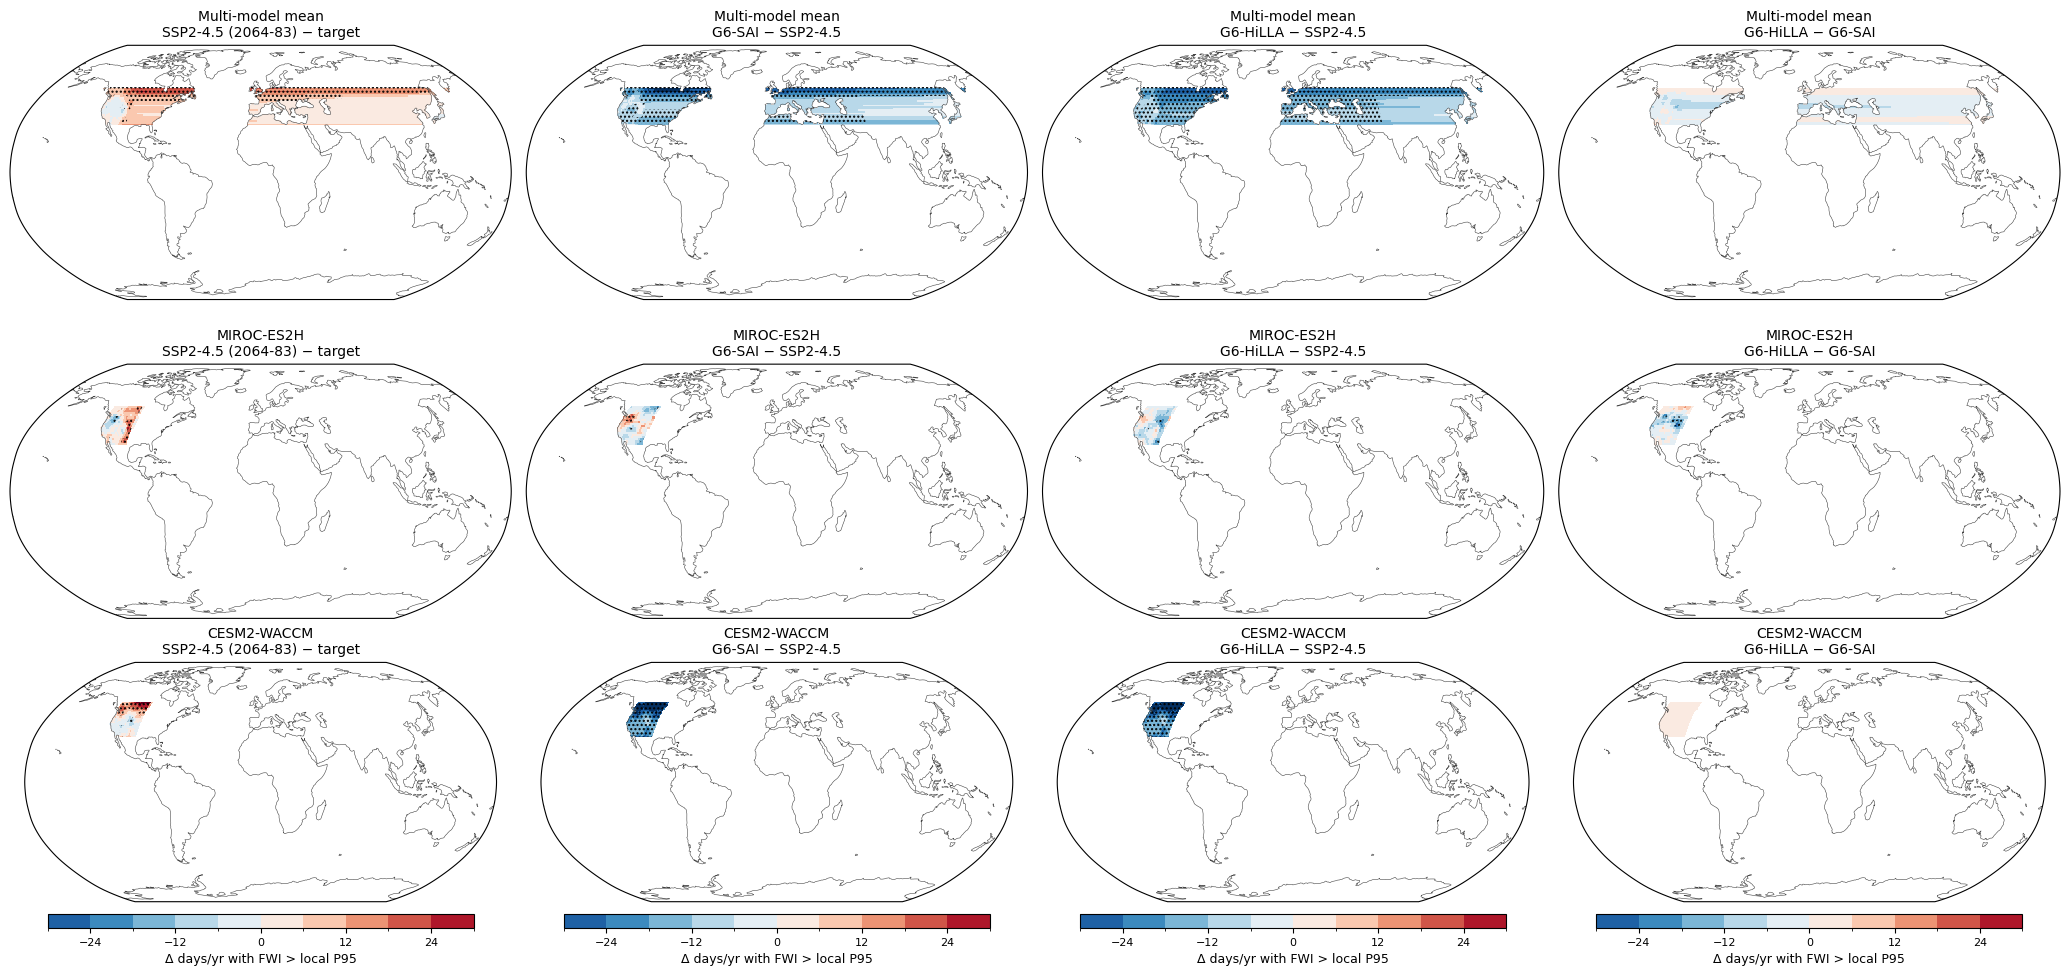

In [9]:
FIG_PAIRS = ["ssp245_minus_target", "SAI_minus_ssp245", "HiLLA_minus_ssp245", "HiLLA_minus_SAI"]

def delta_figure(var, label, fname, cmap="RdBu_r", floor=None, per_model=True):
    panels = [("Multi-model mean" if len(models) > 1 else models[0], mm, mm_land, "robust_")]
    if per_model and len(models) > 1:
        panels += [(m, summary[m], summary[m]["land"], "sig_") for m in models]
    vlim = P.symmetric_limit(xr.concat([mm[f"d_{var}_{p}"].where(mm_land) for p in FIG_PAIRS], "p"), floor=floor)
    fig, axes = P.map_axes(len(panels), len(FIG_PAIRS))
    for i, (name, ds, land, sigpre) in enumerate(panels):
        for j, pair in enumerate(FIG_PAIRS):
            skey = f"{sigpre}{var if var != 'fwi_fs' or sigpre == 'robust_' else 'days_p95'}_{pair}"
            P.map_panel(axes[i, j], ds[f"d_{var}_{pair}"], cmap, -vlim, vlim,
                        title=f"{name}\n{PAIR_TITLE[pair]}", stipple=ds[skey].where(land, False) if skey in ds else None,
                        cbar_label=label, land=land, cbar=(i == len(panels) - 1))
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/{fname}.png", dpi=200, bbox_inches="tight")
    plt.show()

delta_figure("days_p95", "Δ days/yr with FWI > local P95", "fig1_delta_p95_days", floor=1)

### Figure 2 — Change in fire-season mean FWI
The fire season is the 3 consecutive months with the highest target-period FWI at each grid cell. Its stippling reuses the P95-days robustness mask, so treat it as a guide only.

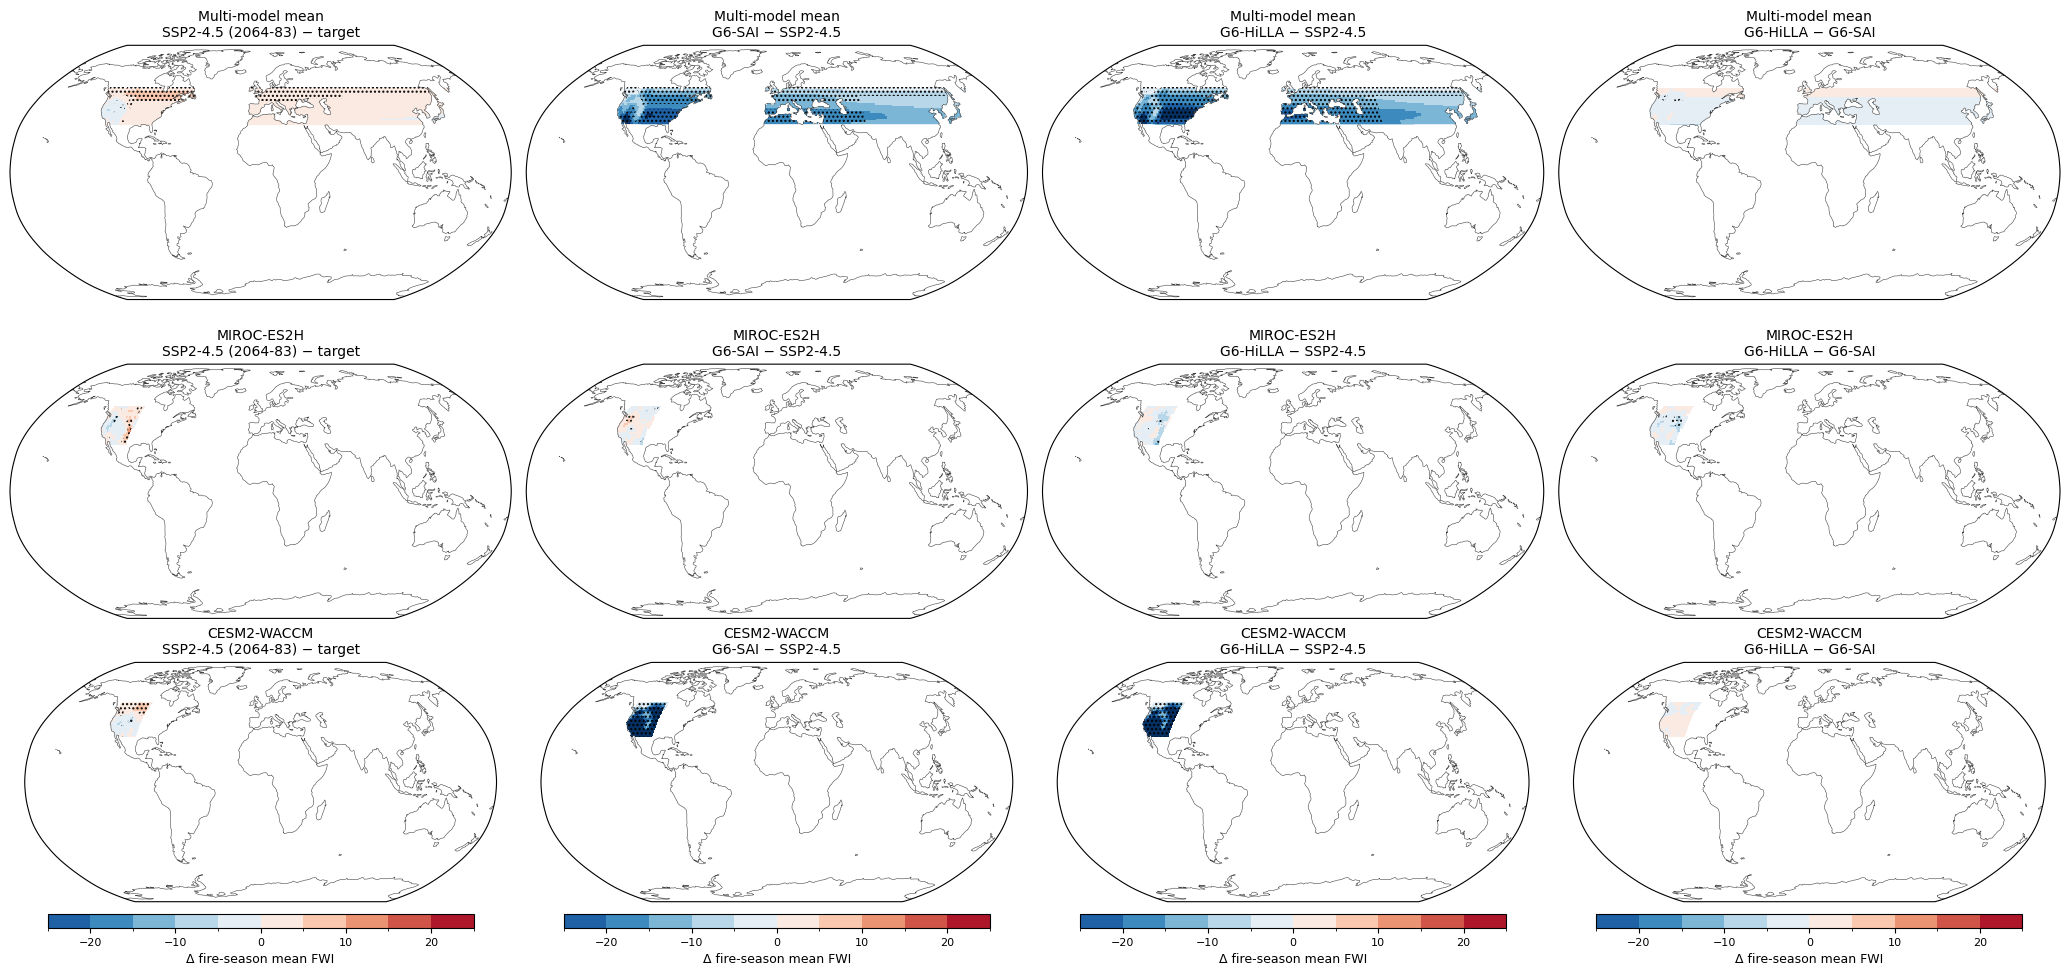

In [10]:
delta_figure("fwi_fs", "Δ fire-season mean FWI", "fig2_delta_fireseason_fwi", floor=0.5)

### Figure 3 — Duration and absolute danger
Longest annual spell above P95, and days per year with FWI above the absolute threshold.

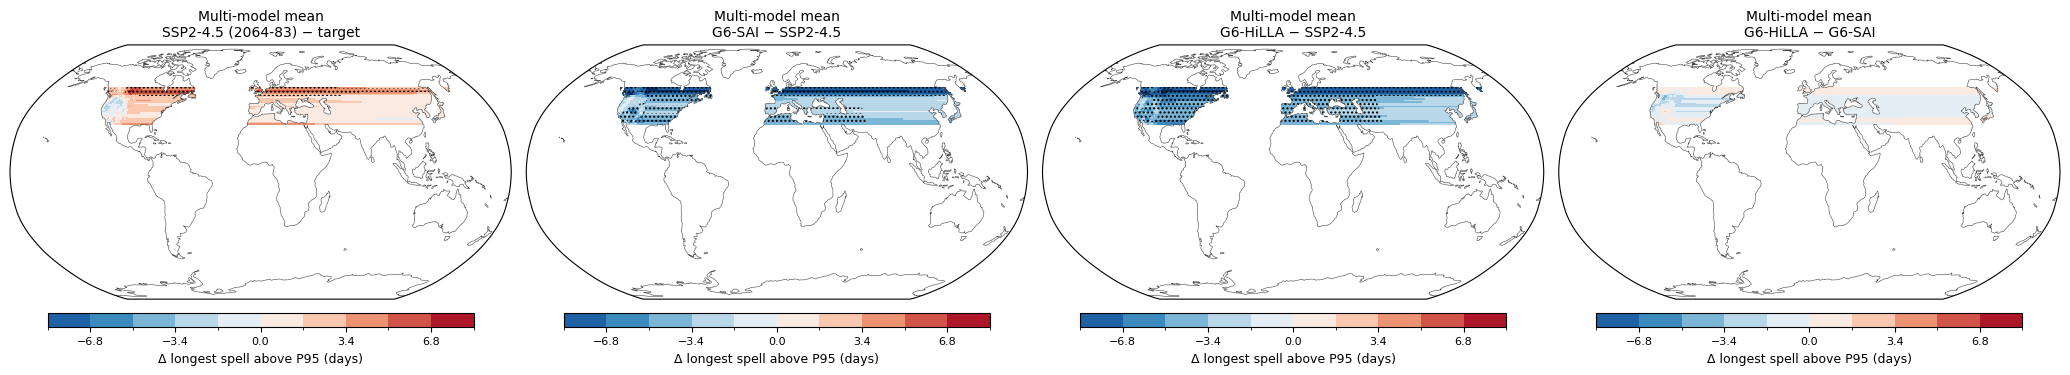

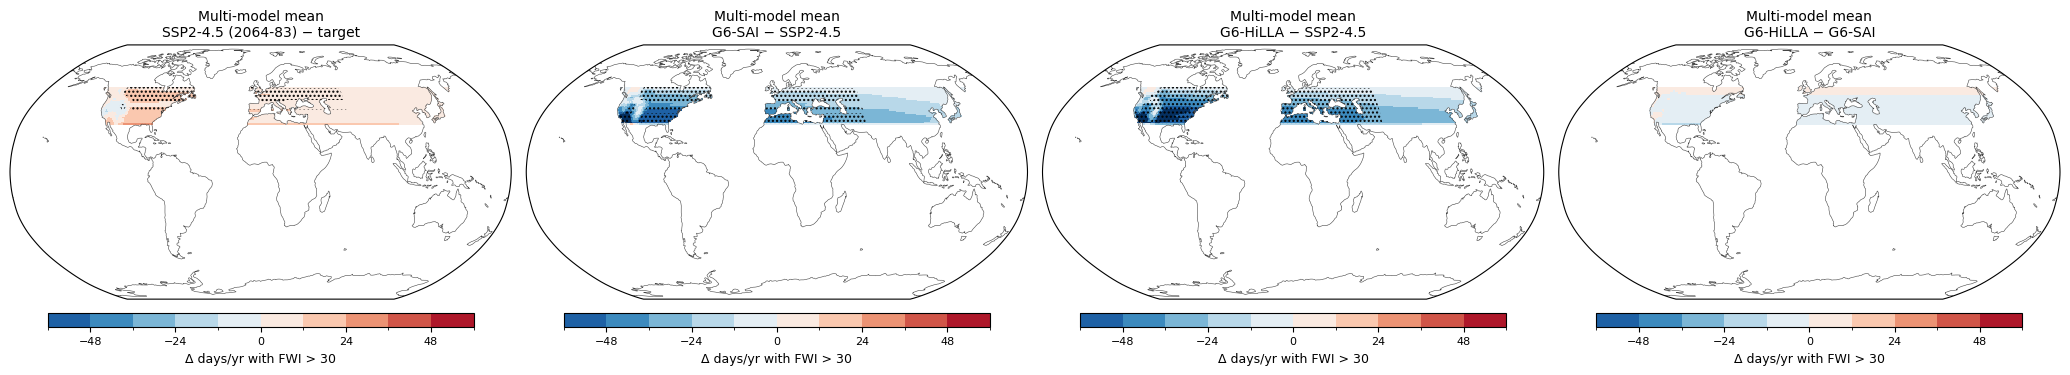

In [11]:
delta_figure("spell_max", "Δ longest spell above P95 (days)", "fig3a_delta_spell", floor=0.5, per_model=False)
delta_figure("days_abs", f"Δ days/yr with FWI > {ABS_FWI:g}", "fig3b_delta_abs_days", floor=1, per_model=False)

### Figure S1 — Context: target-period P95 threshold, fire season, and residual change after SAI

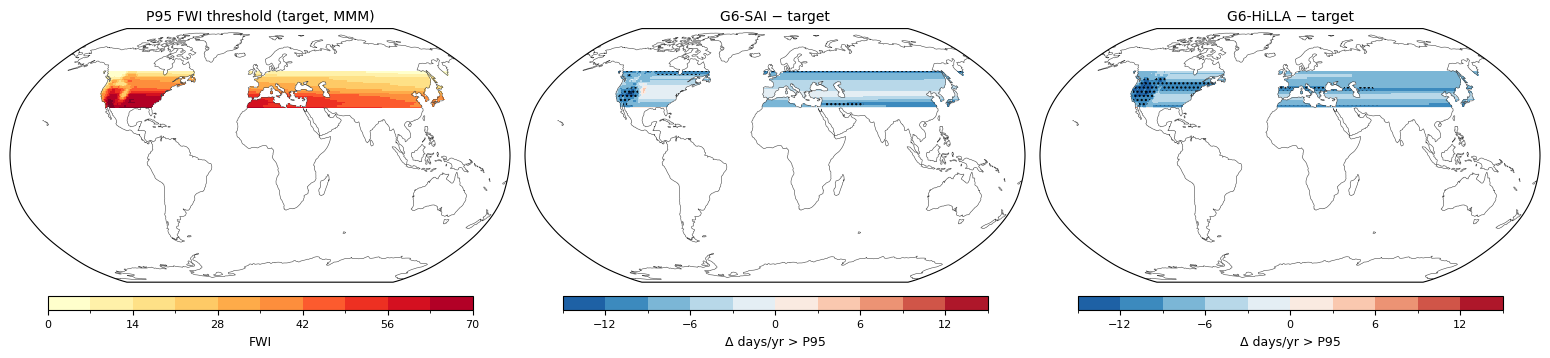

In [12]:
fig, axes = P.map_axes(1, 3)
t = mm["p95_threshold"].where(mm_land)
P.map_panel(axes[0, 0], t, "YlOrRd", 0, P.symmetric_limit(t, 98), "P95 FWI threshold (target, MMM)",
            cbar_label="FWI", extend="max")
for k, pair in enumerate(["SAI_minus_target", "HiLLA_minus_target"]):
    vlim = P.symmetric_limit(mm[f"d_days_p95_{pair}"].where(mm_land), floor=1)
    P.map_panel(axes[0, k+1], mm[f"d_days_p95_{pair}"], "RdBu_r", -vlim, vlim, PAIR_TITLE[pair],
                stipple=mm[f"robust_days_p95_{pair}"].where(mm_land, False), cbar_label="Δ days/yr > P95", land=mm_land)
fig.tight_layout(); fig.savefig(f"{FIG_DIR}/figS1_context.png", dpi=200, bbox_inches="tight"); plt.show()

## 6. AR6 regional statistics
Area-weighted, land-only means over AR6 land regions. The CSV covers every region; the figure shows `FOCUS_REGIONS`.

In [13]:
recs = []
for m in models:
    s = summary[m]
    for var in ("days_p95", "fwi_fs", "spell_max", "days_abs"):
        for run in RUNS:
            r = P.regional_means(s[f"{var}_{run}"])
            for reg in r.region.values:
                recs.append(dict(model=m, metric=var, quantity=run, region=str(reg),
                                 region_name=str(r.sel(region=reg).region_name.values), value=float(r.sel(region=reg))))
        for pair in PAIRS:
            r = P.regional_means(s[f"d_{var}_{pair}"])
            for reg in r.region.values:
                recs.append(dict(model=m, metric=var, quantity=f"d_{pair}", region=str(reg),
                                 region_name=str(r.sel(region=reg).region_name.values), value=float(r.sel(region=reg))))
reg_df = pd.DataFrame(recs)
reg_df.to_csv(f"{OUT_DIR}/task1_AR6_regional_stats.csv", index=False)
wide = reg_df[(reg_df.metric == "days_p95") & reg_df.region.isin(FOCUS_REGIONS)].pivot_table(
    index=["region"], columns=["quantity"], values="value", aggfunc="mean")
cols = ["target", "ssp245", "G6-1.5K-SAI", "G6-1.5K-HiLLA", "d_SAI_minus_ssp245", "d_HiLLA_minus_ssp245", "d_HiLLA_minus_SAI"]
display(wide.reindex(FOCUS_REGIONS)[cols].round(2).rename_axis("P95 days/yr (model mean)"))

quantity,target,ssp245,G6-1.5K-SAI,G6-1.5K-HiLLA,d_SAI_minus_ssp245,d_HiLLA_minus_ssp245,d_HiLLA_minus_SAI
P95 days/yr (model mean),,,,,,,
NWN,18.28,31.85,9.71,11.48,-22.14,-20.37,1.78
NEN,18.27,40.73,10.16,12.94,-30.57,-27.79,2.78
WSB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ESB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WNA,18.28,18.98,10.06,7.23,-8.92,-11.75,-2.83
MED,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NSA,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SAM,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NES,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Figure 4 — Regional change in P95 days (focus regions)
Bars show the multi-model mean. Dots show individual models.

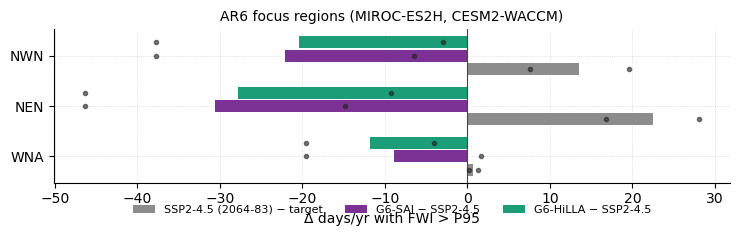

In [14]:
def regional_bars(metric, pairs, label, fname):
    sub = reg_df[(reg_df.metric == metric) & reg_df.region.isin(FOCUS_REGIONS)]
    regs = [r for r in FOCUS_REGIONS if r in sub.region.values][::-1]
    style = {"d_ssp245_minus_target": P.SCEN_STYLE["ssp245"], "d_SAI_minus_ssp245": P.SCEN_STYLE["G6-1.5K-SAI"],
             "d_HiLLA_minus_ssp245": P.SCEN_STYLE["G6-1.5K-HiLLA"]}
    fig, ax = plt.subplots(figsize=(7.5, 0.42 * len(regs) + 1.2))
    h = 0.8 / len(pairs)
    for k, q in enumerate(pairs):
        d = sub[sub.quantity == q]
        y = np.arange(len(regs)) + (k - (len(pairs) - 1) / 2) * h
        mean = [d[d.region == r].value.mean() for r in regs]
        ax.barh(y, mean, height=h * 0.9, color=style[q]["color"], label=PAIR_TITLE[q[2:]])
        for mdl in models:
            vals = [d[(d.region == r) & (d.model == mdl)].value.mean() for r in regs]
            ax.plot(vals, y, "o", ms=3, color="#222222", alpha=0.6, zorder=3)
    ax.axvline(0, color="#444444", lw=0.8)
    ax.set_yticks(np.arange(len(regs)), regs)
    ax.set_xlabel(label)
    P.style_axes(ax)
    ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=len(pairs))
    ax.set_title(f"AR6 focus regions ({', '.join(models)})", fontsize=10)
    fig.tight_layout(); fig.savefig(f"{FIG_DIR}/{fname}.png", dpi=200, bbox_inches="tight"); plt.show()

regional_bars("days_p95", ["d_ssp245_minus_target", "d_SAI_minus_ssp245", "d_HiLLA_minus_ssp245"],
              "Δ days/yr with FWI > P95", "fig4_regional_delta_p95_days")

### Figure 5 — Seasonality of extreme fire weather (focus regions)
Mean days per month above the target-period P95, for each run. Shifts in onset, peak and duration are visible here. This previews the Task 4 fire-shift time series.

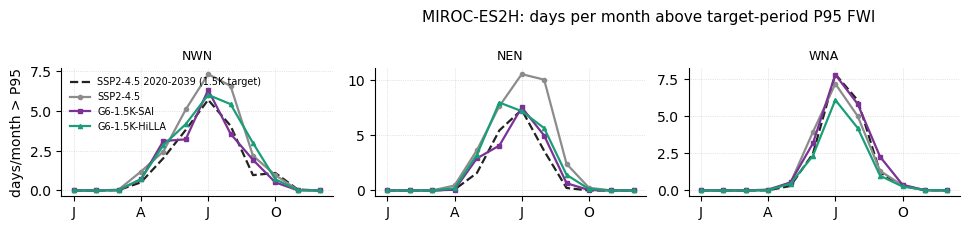

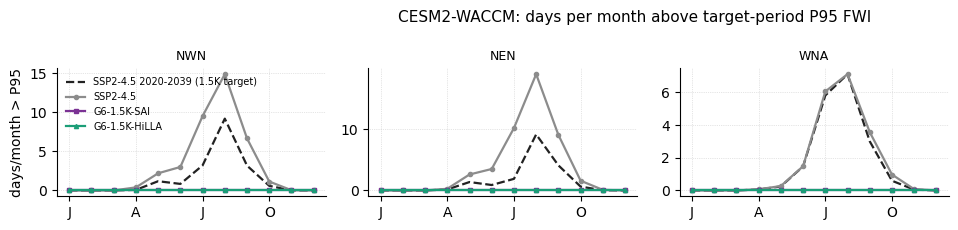

In [15]:
DAYS_M = np.array([31, 28.25, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
for m in models:
    s = summary[m]
    reg = {run: P.regional_means(s[f"exc_freq_{run}"], FOCUS_REGIONS) * xr.DataArray(DAYS_M, dims="month",
           coords={"month": np.arange(1, 13)}) for run in RUNS}
    regs = list(reg["target"].region.values)
    ncol = 4; nrow = int(np.ceil(len(regs) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 2.3 * nrow), sharex=True, squeeze=False)
    for i, r in enumerate(regs):
        ax = axes.flat[i]
        for run in RUNS:
            st = P.SCEN_STYLE[run]
            ax.plot(np.arange(1, 13), reg[run].sel(region=r), color=st["color"], ls=st["ls"], marker=st["marker"],
                    ms=3, lw=1.6, label=P.SCEN_LABEL[run])
        ax.set_title(f"{r}", fontsize=9)
        ax.set_xticks([1, 4, 7, 10], ["J", "A", "J", "O"])
        P.style_axes(ax)
    for ax in axes.flat[len(regs):]:
        ax.set_visible(False)
    axes[0, 0].set_ylabel("days/month > P95")
    axes.flat[0].legend(fontsize=7, frameon=False, loc="upper left")
    fig.suptitle(f"{m}: days per month above target-period P95 FWI", fontsize=11)
    fig.tight_layout(); fig.savefig(f"{FIG_DIR}/fig5_seasonality_{m}.png", dpi=200, bbox_inches="tight"); plt.show()

## 7. *(Optional)* Driver attribution: cooling vs. drying
**Delta method.** The baseline is SSP2-4.5 2064–2083 daily weather (one member). For each G6 scenario, the monthly-climatological change (G6 minus SSP2-4.5, ensemble means) is applied to **one driver at a time**: additive for tasmax and RH, multiplicative for wind and precipitation. FWI is then recomputed. The contribution of each driver is FWI(perturbed) − FWI(baseline). Perturbing "all" drivers approximates the total mean-state change. The gap between "all" and the actual G6 change reflects changes in daily variability.

In [16]:
ATTR_DRIVERS = {"Temperature": None, "Humidity": None, "Wind": ["sfcWind"], "Precipitation": ["pr"]}
attrib = {}
if RUN_ATTRIBUTION:
    for m in models:
        mem0 = members[m]["ssp245"][ATTRIB_MEMBER]
        yrs_in = (ASSESS_PERIOD[0] - P.SPINUP_YEARS, ASSESS_PERIOD[1])
        base = ws.inputs(m, "ssp245", mem0, yrs_in, INPUT_VARS)
        rhv = FWI_RH if FWI_RH in base else FWI_RH_FALLBACK
        ATTR_DRIVERS["Humidity"], ATTR_DRIVERS["Temperature"] = [rhv], [fwi_temp[m]]
        fvars = [fwi_temp[m], rhv, "sfcWind", "pr"]
        def clim(scen):
            cl = [P.monthly_climatology(ws.inputs(m, scen, mm_, yrs_in, INPUT_VARS)[fvars].sel(
                  time=slice(str(ASSESS_PERIOD[0]), None))) for mm_ in members[m][scen]]
            return xr.concat(cl, "member").mean("member")
        path = f"{OUT_DIR}/metrics{ws.tag}/{m}/attribution_q{int(P95*100)}.nc"
        def run_attr():
            clim_ssp = clim("ssp245").compute()
            res = {}
            season = summary[m]["fire_season"]
            def fwi_metrics(ds_in):
                f = P.compute_fwi(ds_in, fwi_temp[m], FWI_RH, FWI_RH_FALLBACK, space_chunk=SPACE_CHUNK,
                                  analysis_start=ASSESS_PERIOD[0])["FWI"]
                mt = P.exceedance_metrics(f, thr[m], None, spells=False)
                return xr.Dataset({"days_p95": mt["days_p95"].mean("year"),
                                   "fwi_fs": P.seasonal_mean(mt["mean_month"], season)}).compute()
            b = fwi_metrics(base)
            for scen in ("G6-1.5K-SAI", "G6-1.5K-HiLLA"):
                deltas = P.climatological_deltas(clim(scen).compute(), clim_ssp, fvars)
                sets = dict(ATTR_DRIVERS, All=fvars)
                for name, vs in sets.items():
                    r = fwi_metrics(P.apply_deltas(base, deltas, vs)) - b
                    for k in r:
                        res[f"{k}_{scen}_{name}"] = r[k]
                    print(f"  {m} {scen} {name} done")
            return xr.Dataset(res)
        attrib[m] = P.cached_netcdf(path, run_attr, OVERWRITE_METRICS)

### Figure 6 — Which driver controls the change in fire-season FWI? (focus regions)

In [17]:
if RUN_ATTRIBUTION:
    DRV_COL = {"Temperature": "#d6604d", "Humidity": "#4393c3", "Wind": "#8c8c8c", "Precipitation": "#1b7837",
               "All": "#222222"}
    for m in models:
        fig, axes = plt.subplots(1, 2, figsize=(11, 0.4 * len(FOCUS_REGIONS) + 1.4), sharey=True)
        for ax, scen, pair in zip(axes, ("G6-1.5K-SAI", "G6-1.5K-HiLLA"), ("SAI_minus_ssp245", "HiLLA_minus_ssp245")):
            names = list(ATTR_DRIVERS) + ["All"]
            regs = None
            h = 0.8 / (len(names) + 1)
            for k, nme in enumerate(names):
                r = P.regional_means(attrib[m][f"fwi_fs_{scen}_{nme}"], FOCUS_REGIONS)
                regs = list(r.region.values)[::-1]
                y = np.arange(len(regs)) + (k - len(names) / 2) * h
                ax.barh(y, r.sel(region=regs), height=h * 0.9, color=DRV_COL[nme], label=nme)
            actual = P.regional_means(summary[m][f"d_fwi_fs_{pair}"], FOCUS_REGIONS).sel(region=regs)
            ax.plot(actual, np.arange(len(regs)) + (len(names) / 2) * h, "D", color="#7b3294" if "SAI" in scen else "#1b9e77",
                    ms=5, label="Actual G6 − SSP2-4.5", zorder=4)
            ax.axvline(0, color="#444444", lw=0.8)
            ax.set_yticks(np.arange(len(regs)), regs)
            ax.set_title(f"{m}: {P.SCEN_LABEL[scen]} − SSP2-4.5", fontsize=10)
            ax.set_xlabel("Δ fire-season mean FWI")
            P.style_axes(ax)
        h_, l_ = axes[1].get_legend_handles_labels()
        fig.legend(h_, l_, fontsize=8, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=len(l_))
        fig.tight_layout(); fig.savefig(f"{FIG_DIR}/fig6_attribution_{m}.png", dpi=200, bbox_inches="tight"); plt.show()

## 8. Outputs for the mid-project report and Task 4
| file | content |
|---|---|
| `WORK_ROOT/fwi/<model>/<scenario>/<member>_<years>.zarr` | daily FWI (Living Data Product / pyrE / Task 4) |
| `pyrosai_output/task1_<model>_summary.nc` | per-model maps: thresholds, P95/absolute days, spells, fire-season FWI, all deltas, p-values, FDR masks, monthly exceedance |
| `pyrosai_output/task1_multimodel_1deg.nc` | multi-model means and robustness on the 1°×1° atlas grid |
| `pyrosai_output/task1_AR6_regional_stats.csv` | all AR6 land regions, all metrics |
| `pyrosai_output/figures/fig*.png` | report figures |

**Methods text (draft):** *Daily FWI was computed with xclim v{xclim} from daily maximum near-surface temperature, daily minimum (or mean) relative humidity, daily-mean 10 m wind speed and daily precipitation. Moisture codes were initialised with standard start-up values and spun up for one year, which was discarded. Local extreme fire-weather thresholds are the 95th percentile of daily FWI, pooled across ensemble members of SSP2-4.5 during 2020–2039, the reference climate targeted by G6-1.5K. Changes were assessed for 2064–2083. Statistical significance of changes in annual metrics used Welch's t-test with Benjamini–Hochberg false discovery rate control (α_FDR = 0.1).*

In [18]:
print("Figures:")
for f in sorted(os.listdir(FIG_DIR)):
    print("  ", f)
print("Files:")
for f in sorted(os.listdir(OUT_DIR)):
    if f.endswith((".nc", ".csv")):
        print("  ", f)

Figures:
   fig1_delta_p95_days.png
   fig2_delta_fireseason_fwi.png
   fig3a_delta_spell.png
   fig3b_delta_abs_days.png
   fig4_regional_delta_p95_days.png
   fig5_seasonality_CESM2-WACCM.png
   fig5_seasonality_MIROC-ES2H.png
   figS1_context.png
Files:
   task1_AR6_regional_stats.csv
   task1_CESM2-WACCM_summary.nc
   task1_MIROC-ES2H_summary.nc
   task1_multimodel_1deg.nc
